# Individual Analysis of IntroDH Project
### Xinran Liu
### r1069247

## 2. Descriptive Analysis of the DramaDataset

### 2.1 Data processing for the analysis of Number of Publications over Decade

In [2]:
import pandas as pd
import numpy as np

input_file = 'dh_group7_drama_251229.csv'
df = pd.read_csv(input_file)

print(f"Original Row Count: {len(df)}")


df['Cleaned_Author'] = df['author (n)']

if 'other author (n)' in df.columns:
    df['Cleaned_Author'] = df['Cleaned_Author'].fillna(df['other author (n)'])

df['Cleaned_Author'] = df['Cleaned_Author'].fillna('Unknown')

# drop rows without year
df = df.dropna(subset=['p year'])

# convert year to integer
df['Publication_Year'] = df['p year'].astype(int)

# create decade column
df['Decade_Label'] = ((df['Publication_Year'] // 10) * 10).astype(str) + 's'

if 'p location' in df.columns:
    df['Publisher_Location'] = df['p location'].fillna('Unknown').astype(str)

if 'p name' in df.columns:
    df['Publisher_Name'] = df['p name'].fillna('Unknown').astype(str)

if 'title (n)' in df.columns:
    df['Cleaned_Title'] = df['title (n)'].fillna('Unknown').astype(str)

if 'type' in df.columns:
    df['Genre_Type'] = df['type'].fillna('Unknown').astype(str)

columns_to_keep = [
    'Publication_Year', 
    'Decade_Label', 
    'Cleaned_Author', 
    'Cleaned_Title', 
    'Publisher_Location', 
    'Publisher_Name',
    'Genre_Type'
]

final_columns = []
for col in columns_to_keep:
    if col in df.columns:
        final_columns.append(col)

df_final = df[final_columns]

df_final.to_csv('drama_master_cleaned_final.csv', index=False)

print("Final Row Count:", len(df_final))
print(df_final.head())

Original Row Count: 1615
Final Row Count: 1611
   Publication_Year Decade_Label                  Cleaned_Author  \
0              1791        1790s             inchbald, elizabeth   
1              1809        1800s                         Unknown   
2              1788        1780s  claris de florian, jean pierre   
3              1641        1640s                         Unknown   
4              1788        1780s                         sedaine   

                                       Cleaned_Title Publisher_Location  \
0      next door neighbours; a comedy; in three acts             london   
1          the traveller; or, the marriage in sicily             london   
2          look before you leap. a comedy in one act             london   
3  mercurius britanicus; or, the english intellig...             london   
4            a key to the lock, a comedy in two acts             london   

   Publisher_Name Genre_Type  
0         Unknown     comedy  
1         Unknown     comedy  


### 2.2. Data processing for the analysis of authors over decade

In [3]:
# Separate 'Unknown' from Identified Authors
unknown_df = df_final[df_final['Cleaned_Author'] == 'Unknown']
identified_df = df_final[df_final['Cleaned_Author'] != 'Unknown']

total_records = len(df_final)
unknown_count = len(unknown_df)
identified_count = len(identified_df)
unique_authors_count = identified_df['Cleaned_Author'].nunique()

unknown_percentage = (unknown_count / total_records) * 100

print(f"Total Records: {total_records}")
print(f"Identified Works: {identified_count}")
print(f"Unknown/Missing Authors: {unknown_count} ({unknown_percentage:.2f}%)")
print(f"Total Unique Identified Authors: {unique_authors_count}")

# Find Top Authors
author_counts = identified_df['Cleaned_Author'].value_counts()

print(f"\nTop 10 Most Prolific Authors")
print(author_counts.head(10))

# How many plays the average author writes
avg_productivity = identified_count / unique_authors_count
print(f"\nAverage plays per author: {avg_productivity:.2f}")

# Decade Analysis (Who was active when?)
authors_per_decade = df_final.groupby('Decade_Label')['Cleaned_Author'].nunique()

print(f"\nUnique Authors Active per Decade")
print(authors_per_decade.sort_index())

Total Records: 1611
Identified Works: 1381
Unknown/Missing Authors: 230 (14.28%)
Total Unique Identified Authors: 850

Top 10 Most Prolific Authors
Cleaned_Author
cumberland, richard    24
dryden, john           21
shadwell, thomas       19
shirley, james         18
foote, samuel          14
lee, nathaniel         14
william shakespeare    14
d'urfey, thomas        11
murphy, arthur         11
behn, aphra            10
Name: count, dtype: int64

Average plays per author: 1.62

Unique Authors Active per Decade
Decade_Label
1540s      1
1590s      1
1600s      6
1610s      5
1620s      5
1630s     30
1640s     17
1650s     22
1660s     29
1670s     41
1680s     32
1690s     36
1700s     21
1710s      8
1720s      6
1730s     10
1740s      7
1750s     16
1760s     19
1770s     25
1780s     37
1790s     45
1800s     64
1810s     69
1820s     61
1830s     34
1840s     24
1850s     44
1860s     31
1870s     60
1880s     92
1890s    171
1900s      4
1910s      1
1920s      1
Name: Cleaned_Aut

### 2.3 Publishers and publication trends over time

In [4]:
import pandas as pd
file_path = 'drama_master_cleaned_final.csv'
df = pd.read_csv(file_path)

df['Publisher_Name'] = df['Publisher_Name'].fillna('Unknown')
# Calculate Total Publishers and Missing Rate
total_rows = len(df)

unknown_rows = len(df[df['Publisher_Name'] == 'Unknown'])

missing_rate_global = (unknown_rows / total_rows) * 100

known_publishers_df = df[df['Publisher_Name'] != 'Unknown']
total_publishers_count = known_publishers_df['Publisher_Name'].nunique()

print(f"Total Unique Publishers: {total_publishers_count}")
print(f"Global Missing Data Rate: {missing_rate_global:.2f}%")

# Find Top 10 Publishers
top_publishers = known_publishers_df['Publisher_Name'].value_counts().reset_index()
top_publishers.columns = ['Publisher_Name', 'Publication_Count']

top_10_df = top_publishers.head(10)

top_10_df.to_csv('viz_top10_publishers.csv', index=False)
print("Saved: 'viz_top10_publishers.csv'")

# CR3 Analysis per Decade
results_list = []

decades = sorted(df['Decade_Label'].unique())

for decade in decades:
    
    # Get data for this specific decade
    decade_data = df[df['Decade_Label'] == decade]
    total_in_decade = len(decade_data)
    
    # Calculate Missing Rate for this decade
    unknown_in_decade = len(decade_data[decade_data['Publisher_Name'] == 'Unknown'])
    decade_missing_rate = (unknown_in_decade / total_in_decade) * 100
    
    # Calculate Market Share for known publishers
    known_data = decade_data[decade_data['Publisher_Name'] != 'Unknown']
    
    # Count publications for each publisher in this decade
    publisher_counts = known_data['Publisher_Name'].value_counts()
    
    # Find Top 3 and calculate CR3
    if len(publisher_counts) == 0:
        cr3_value = 0
        top1 = "None"
        top2 = "None"
        top3 = "None"
    else:
        market_shares = (publisher_counts / total_in_decade) * 100
        
        # Take the top 3
        top_3_shares = market_shares.head(3)
        cr3_value = top_3_shares.sum()
        
        names = top_3_shares.index.tolist()
        top1 = names[0] if len(names) > 0 else "None"
        top2 = names[1] if len(names) > 1 else "None"
        top3 = names[2] if len(names) > 2 else "None"

    # Determine Market Structure
    if cr3_value > 60:
        structure = "Oligopoly"
    elif cr3_value < 40:
        structure = "Free Competition"
    else:
        structure = "Moderate"

    # Append data to the list
    results_list.append({
        'Decade_Label': decade,
        'CR3_Percentage': cr3_value,
        'Missing_Rate_Percentage': decade_missing_rate,
        'Market_Structure': structure,
        'Top1_Publisher': top1,
        'Top2_Publisher': top2,
        'Top3_Publisher': top3
    })

cr3_df = pd.DataFrame(results_list)

cr3_df.to_csv('viz_cr3_market_analysis.csv', index=False)
print("Saved: 'viz_cr3_market_analysis.csv'")

print("\nPreview of CR3 Data:")
print(cr3_df.head())

Total Unique Publishers: 624
Global Missing Data Rate: 42.33%
Saved: 'viz_top10_publishers.csv'
Saved: 'viz_cr3_market_analysis.csv'

Preview of CR3 Data:
  Decade_Label  CR3_Percentage  Missing_Rate_Percentage Market_Structure  \
0        1540s           100.0                 0.000000        Oligopoly   
1        1590s           100.0                 0.000000        Oligopoly   
2        1600s            50.0                33.333333         Moderate   
3        1610s            50.0                 0.000000         Moderate   
4        1620s            60.0                20.000000         Moderate   

               Top1_Publisher            Top2_Publisher  \
0  in ædibus tho. berthel[et]                      None   
1                 john danter                      None   
2                  mathew law    j. windet for e. blunt   
3             for iohn browne  w. stansby for j. parker   
4               for m. rhodes   n. o.  for thomas thorp   

                                 

### 3.1 Length of title over time

Max Title Length: 43 words
Min Title Length: 1 words
Avg Title Length: 7.90 words
Longest Title (1622): the troublesome raigne and lamentable death of edw...


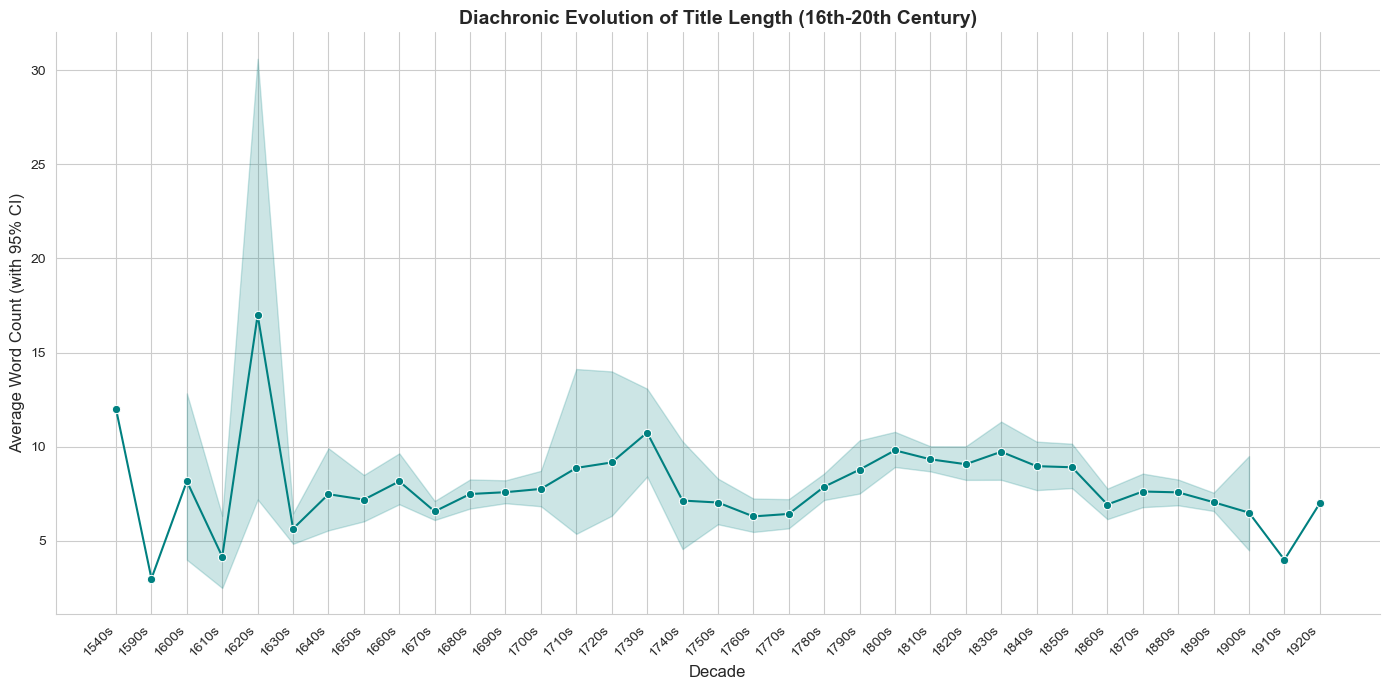

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('drama_master_cleaned_final.csv')

df['Cleaned_Title'] = df['Cleaned_Title'].astype(str).fillna('')
df['Publication_Year'] = pd.to_numeric(df['Publication_Year'], errors='coerce')

# Calculate Title Length
df['Title_Length'] = df['Cleaned_Title'].apply(lambda x: len(x.strip().split()))

#Ensure data is sorted by year
df = df.sort_values('Publication_Year')

print(f"Max Title Length: {df['Title_Length'].max()} words")
print(f"Min Title Length: {df['Title_Length'].min()} words")
print(f"Avg Title Length: {df['Title_Length'].mean():.2f} words")

# Identify the longest title
longest_row = df.loc[df['Title_Length'].idxmax()]
print(f"Longest Title ({longest_row['Publication_Year']}): {longest_row['Cleaned_Title'][:50]}...")

plt.figure(figsize=(14, 7))

sns.set_style("whitegrid") 

# errorbar=('ci', 95): This explicitly calculates the 95% Confidence Interval via bootstrapping.
# The shadow represents where the true population mean is likely to fall 95% of the time.
sns.lineplot(
    data=df, 
    x='Decade_Label', 
    y='Title_Length', 
    color='teal', 
    marker='o',
    errorbar=('ci', 95) 
)

plt.title('Diachronic Evolution of Title Length (16th-20th Century)', fontsize=14, weight='bold')
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Average Word Count (with 95% CI)', fontsize=12) # Clearly label the Y-axis metrics

plt.xticks(rotation=45, ha='right')

sns.despine()

plt.tight_layout()
plt.show()

### 3.2 Geographic terms in the titles

In [6]:
from collections import Counter
import re

all_titles = ' '.join(df['Cleaned_Title']).lower()

# extract words and count their frequency
words = re.findall(r'\w+', all_titles)
word_counts = Counter(words)

# top 500
print(word_counts.most_common(500))


[('a', 1365), ('the', 1322), ('of', 598), ('in', 504), ('tragedy', 434), ('comedy', 416), ('acts', 392), ('or', 356), ('and', 268), ('etc', 266), ('five', 232), ('drama', 187), ('play', 127), ('three', 120), ('dramatic', 110), ('s', 104), ('an', 93), ('historical', 61), ('plays', 60), ('to', 55), ('two', 55), ('poem', 48), ('for', 47), ('king', 45), ('d', 42), ('comedie', 39), ('love', 37), ('on', 37), ('poems', 37), ('other', 37), ('with', 32), ('new', 32), ('musical', 30), ('four', 29), ('by', 28), ('from', 27), ('tragi', 27), ('wife', 26), ('life', 23), ('story', 22), ('one', 22), ('original', 22), ('man', 21), ('sir', 19), ('queen', 19), ('fatal', 19), ('novel', 18), ('his', 17), ('being', 17), ('all', 17), ('history', 17), ('country', 17), ('husband', 17), ('tale', 17), ('revenge', 16), ('fall', 16), ('first', 16), ('english', 16), ('at', 16), ('works', 16), ('shakespeare', 16), ('great', 15), ('death', 15), ('school', 15), ('daughter', 15), ('lovers', 14), ('lady', 14), ('tragic'

### Strategy for building bag-of-words for extracting GEO Terms

In [10]:
import pandas as pd
import re
from collections import Counter

# PART 1: Generate Top 500 Word List for Inspection

# Join all titles into one string and convert to lowercase
all_text = ' '.join(df['Cleaned_Title'].astype(str)).lower()

words = re.findall(r'\b\w+\b', all_text)

basic_stopwords = {
    'the', 'a', 'an', 'of', 'and', 'in', 'to', 'or', 'for', 'with', 
    'on', 'at', 'by', 'from', 's', 'is', 'it', 'that', 'as', 'be', 'are'
}

# Filter out stopwords and single letters
filtered_words = [w for w in words if w not in basic_stopwords and len(w) > 1]

# Count Frequencies
counter_obj = Counter(filtered_words)
word_counts_top500 = counter_obj.most_common(500)

print("Word : Frequency")

for rank, (word, freq) in enumerate(word_counts_top500, 1):
    print(f"({rank}) {word} : {freq}")


Word : Frequency
(1) tragedy : 434
(2) comedy : 416
(3) acts : 392
(4) etc : 266
(5) five : 232
(6) drama : 187
(7) play : 127
(8) three : 120
(9) dramatic : 110
(10) historical : 61
(11) plays : 60
(12) two : 55
(13) poem : 48
(14) king : 45
(15) comedie : 39
(16) love : 37
(17) poems : 37
(18) other : 37
(19) new : 32
(20) musical : 30
(21) four : 29
(22) tragi : 27
(23) wife : 26
(24) life : 23
(25) story : 22
(26) one : 22
(27) original : 22
(28) man : 21
(29) sir : 19
(30) queen : 19
(31) fatal : 19
(32) novel : 18
(33) his : 17
(34) being : 17
(35) all : 17
(36) history : 17
(37) country : 17
(38) husband : 17
(39) tale : 17
(40) revenge : 16
(41) fall : 16
(42) first : 16
(43) english : 16
(44) works : 16
(45) shakespeare : 16
(46) great : 15
(47) death : 15
(48) school : 15
(49) daughter : 15
(50) lovers : 14
(51) lady : 14
(52) tragic : 14
(53) pleasant : 13
(54) written : 13
(55) old : 13
(56) st : 13
(57) de : 13
(58) shakspeare : 13
(59) act : 13
(60) duke : 12
(61) lover :

In [13]:
import pandas as pd
import re
from collections import Counter

# PART 2.1 : Generate Dictionaries & Classification
                                  
all_text = ' '.join(df['Cleaned_Title'].astype(str)).lower()
words = re.findall(r'\b\w+\b', all_text)
basic_stopwords = {
    'the', 'a', 'an', 'of', 'and', 'in', 'to', 'or', 'for', 'with', 
    'on', 'at', 'by', 'from', 's', 'is', 'it', 'that', 'as', 'be', 'are'
}
filtered_words = [w for w in words if w not in basic_stopwords and len(w) > 1]
counter_obj = Counter(filtered_words)
word_counts_top500 = counter_obj.most_common(500)

continental_terms = {
    'france', 'italy', 'spain', 'germany', 'greece', 'england', 'scotland', 'ireland', 'holland', 'netherlands', 
    'poland', 'russia', 'muscovy', 'sweden', 'denmark', 'portugal', 'austria', 'hungary', 'swiss', 'flanders',  
    'rome', 'paris', 'venice', 'naples', 'florence', 'verona', 'sicily', 'vienna', 'madrid', 'lisbon', 'seville', 
    'athens', 'sparta', 'troy', 'french', 'spanish', 'italian', 'german', 'dutch', 'english', 'scottish', 'irish', 
    'roman', 'grecian', 'greek', 'venetian', 'sicilian', 'polish', 'russian', 'dane', 'danish', 'portuguese', 
    'castilian', 'aragonese'
}

colonial_terms = {
    'america', 'new world', 'west indies', 'indies', 'western', 'atlantic', 'virginia', 'canada', 'quebec', 
    'carolina', 'florida', 'new york', 'boston', 'peru', 'mexico', 'brazil', 'panama', 'guiana', 'amazon', 
    'inca', 'aztec', 'montezuma', 'cortez', 'pizarro', 'jamaica', 'caribbean', 'barbados', 'cuba', 'haiti', 
    'domingo', 'bermudas', 'australia', 'botany bay', 'van diemen', 'colony', 'colonization', 'conquest', 
    'plantation', 'planter', 'slave', 'slavery', 'negro', 'savage', 'voyage', 'discovery', 'island', 'isle', 'indian'
}

oriental_terms = {
    'china', 'chinese', 'japan', 'siam', 'cathay', 'tartary', 'tartar', 'mongol', 'india', 'east indies', 
    'mogul', 'agra', 'bengal', 'ceylon', 'persia', 'persian', 'turk', 'turkish', 'turkey', 'ottoman', 'sultan', 
    'mahomet', 'mohammed', 'constantinople', 'byzantium', 'seraglio', 'harem', 'islam', 'arabia', 'syria', 
    'egypt', 'egyptian', 'cairo', 'nile', 'alexandria', 'morocco', 'moor', 'moorish', 'algiers', 'tunis', 
    'tripoli', 'barbary', 'zara', 'babylon', 'assyria', 'cyrus', 'darius', 'xerxes', 'jerusalem', 'hebrew', 
    'jew', 'israel'
}

classified_terms = {
    'Continental': [],
    'Colonial': [],
    'Oriental': []
}

# Loop: Iterate through the cleaned Top 500 list
for word, frequency in word_counts_top500:
    if word in continental_terms:
        classified_terms['Continental'].append((word, frequency)) 
    elif word in colonial_terms:
        classified_terms['Colonial'].append((word, frequency))
    elif word in oriental_terms:
        classified_terms['Oriental'].append((word, frequency))

print("\nContinental Terms Found (Top 500)")
print(classified_terms['Continental'])

print("\nColonial Terms Found (Top 500")
print(classified_terms['Colonial'])

print("\nOriental Terms Found (Top 500)")
print(classified_terms['Oriental'])



Continental Terms Found (Top 500)
[('english', 16), ('french', 9), ('england', 7), ('roman', 6), ('spanish', 6), ('greek', 6), ('venice', 5), ('italian', 5), ('poland', 4), ('irish', 4), ('france', 3), ('rome', 3), ('paris', 3), ('naples', 3), ('sparta', 3), ('russian', 3)]

Colonial Terms Found (Top 500
[('island', 6), ('conquest', 5), ('slave', 5), ('voyage', 4), ('indian', 4), ('discovery', 3)]

Oriental Terms Found (Top 500)
[('jew', 4), ('persia', 4), ('china', 4), ('persian', 3), ('morocco', 3), ('turkey', 3)]


In [17]:
import pandas as pd
import re
from collections import Counter

# STEP 2.2: DICTIONARY EXPANSION (Co-occurrence)

imperial_seeds = [
    'empire', 'colony', 'colonial', 'plantation', 'slave', 'slaves', 
    'indian', 'indies', 'ocean', 'west', 'voyage', 'island', 'virginia', 
    'conquest', 'merchant', 'siege', 'jamaica', 'bengal'
]

oriental_seeds = [
    'sultan', 'mogul', 'harem', 'seraglio', 'east', 'china', 'chinese',
    'persia', 'persian', 'turk', 'turkey', 'morocco', 'algiers', 'algeria', 
    'egypt', 'arab', 'tartar', 'tartary'
]

european_seeds = [
    'europe', 'german', 'dutch', 'french', 'spanish', 'spain', 
    'italian', 'italy', 'venice', 'venetian', 'rome', 'roman', 
    'greek', 'poland', 'russian', 'naples', 'france', 'paris', 
    'sicily', 'sicilian', 'albion', 'hibernia', 'caledonia'
]

# Map them to labels
seed_concepts = {
    'Imperial_Expansion': imperial_seeds,
    'Oriental_Expansion': oriental_seeds,
    'European_Expansion': european_seeds
}

stopwords = set([
    'the', 'and', 'for', 'with', 'that', 'play', 'comedy', 'tragedy', 
    'entitled', 'called', 'act', 'scene', 'part', 'history', 'opera', 
    'farce', 'entertainment', 'sketch', 'acts', 'five', 'three', 'two',
    'one', 'first', 'second', 'new', 'old', 'man', 'woman', 'king', 
    'queen', 'love', 'life', 'death', 'prologue', 'epilogue', 'drama',
    'written', 'performed', 'royal', 'theatre', 'majesty', 'late',
    'great', 'fair', 'young', 'rich', 'poor', 'good', 'bad', 'english', 'etc'
])

for label, seeds in seed_concepts.items():
    print(f"Titles containing {label} seeds")
    related_words = Counter()
    
    # Iterate through every title in the dataframe
    for text in df['Cleaned_Title']:
        text_str = str(text)
        
        title_words = set(re.findall(r'\b[a-z]+\b', text_str))
        if not title_words.isdisjoint(seeds):
            for w in title_words:
                if w not in seeds and w not in stopwords and len(w) > 2:
                    related_words[w] += 1
    
    print(f" Candidates for {label} Dictionary:")
    
    top_candidates = related_words.most_common(60)
    
    print(f"   {', '.join([f'{w}({c})' for w, c in top_candidates])}")


Titles containing Imperial_Expansion seeds
 Candidates for Imperial_Expansion Dictionary:
   tragi(6), airs(3), day(3), musical(3), from(3), historical(3), turkey(2), duets(2), russian(2), chorusses(2), poems(2), china(2), choruses(1), pedlar(1), turn(1), caledonia(1), comedietta(1), widdow(1), ranter(1), bacon(1), cornville(1), prince(1), spleene(1), comedie(1), lover(1), adrasta(1), womens(1), tragicomedy(1), irish(1), expedition(1), surrender(1), mons(1), enchanted(1), tempest(1), floating(1), east(1), sword(1), peace(1), impressions(1), trade(1), duetts(1), kamtchatka(1), tribute(1), southampton(1), trinidad(1), board(1), colour(1), humanity(1), waldeck(1), leyden(1), present(1), before(1), independents(1), dublin(1), thanksgiving(1), onely(1), raised(1), fairing(1), preparatory(1), sent(1)
Titles containing Oriental_Expansion seeds
 Candidates for Oriental_Expansion Dictionary:
   russian(2), slaves(2), day(2), musical(2), playground(2), wanderings(2), zoroaster(2), son(2), oromas

In [22]:
import pandas as pd
import re

# PART 3: Temporal Analysis of Geographic Themes (100% Stacked Data)

df = pd.read_csv('drama_master_cleaned_final.csv')

continental_terms = [
    'english', 'french', 'england', 'roman', 'spanish', 'greek', 'venice',
    'italian', 'poland', 'irish', 'france', 'rome', 'paris', 'naples',
    'sparta', 'russian', 'italy', 'spain', 'germany', 'greece', 'scotland', 'ireland', 'holland',
    'netherlands', 'russia', 'muscovy', 'sweden', 'denmark', 'portugal',
    'austria', 'hungary', 'swiss', 'flanders', 'florence', 'verona',
    'sicily', 'vienna', 'madrid', 'lisbon', 'seville', 'athens', 'troy',
    'german', 'dutch', 'scottish', 'grecian', 'venetian', 'sicilian',
    'polish', 'dane', 'danish', 'portuguese', 'castilian', 'aragonese'
]

colonial_terms = [
    'island', 'conquest', 'slave', 'voyage', 'indian', 'discovery',
    'america', 'new world', 'west indies', 'indies', 'western', 'atlantic',
    'virginia', 'canada', 'quebec', 'carolina', 'florida', 'new york',
    'boston', 'peru', 'mexico', 'brazil', 'panama', 'guiana', 'amazon',
    'inca', 'aztec', 'montezuma', 'cortez', 'pizarro', 'jamaica',
    'caribbean', 'barbados', 'cuba', 'haiti', 'domingo', 'bermudas',
    'australia', 'botany bay', 'van diemen', 'colony', 'colonization',
    'plantation', 'planter', 'slavery', 'negro', 'savage', 'isle'
]

oriental_terms = [
    'jew', 'persia', 'china', 'persian', 'morocco', 'turkey','chinese', 'japan', 
    'siam', 'cathay', 'tartary', 'tartar', 'mongol',
    'india', 'east indies', 'mogul', 'agra', 'bengal', 'ceylon', 'turk',
    'turkish', 'ottoman', 'sultan', 'mahomet', 'mohammed',
    'constantinople', 'byzantium', 'seraglio', 'harem', 'islam',
    'arabia', 'syria', 'egypt', 'egyptian', 'cairo', 'nile',
    'alexandria', 'moor', 'moorish', 'algiers', 'tunis', 'tripoli',
    'barbary', 'zara', 'babylon', 'assyria', 'cyrus', 'darius', 'xerxes',
    'jerusalem', 'hebrew', 'israel'
]
    
def count_terms_in_series(text_series, term_list):

    pattern = r'\b(?:' + '|'.join(term_list) + r')\b'
    
    matches = text_series.astype(str).str.contains(pattern, case=False, na=False, regex=True)
    
    return matches.sum()


counts = df.groupby('Decade_Label').agg(
    Continental=('Cleaned_Title', lambda x: count_terms_in_series(x, continental_terms)),
    Colonial=('Cleaned_Title', lambda x: count_terms_in_series(x, colonial_terms)),
    Oriental=('Cleaned_Title', lambda x: count_terms_in_series(x, oriental_terms))
).reset_index()

counts['Total_Geo_Mentions'] = counts[['Continental', 'Colonial', 'Oriental']].sum(axis=1)

# Filter out decades with 0 mentions to avoid division errors
counts = counts[counts['Total_Geo_Mentions'] > 0].copy()

counts['Pct_Continental'] = counts['Continental'] / counts['Total_Geo_Mentions']
counts['Pct_Colonial'] = counts['Colonial'] / counts['Total_Geo_Mentions']
counts['Pct_Oriental'] = counts['Oriental'] / counts['Total_Geo_Mentions']

print("Processing complete. Preview of results:")
print(counts.head())

counts.to_csv('geo_trends_by_decade.csv', index=False)


Processing complete. Preview of results:
  Decade_Label  Continental  Colonial  Oriental  Total_Geo_Mentions  \
2        1600s            0         1         0                   1   
4        1620s            2         0         0                   2   
5        1630s            1         1         1                   3   
6        1640s            2         1         0                   3   
7        1650s            2         2         0                   4   

   Pct_Continental  Pct_Colonial  Pct_Oriental  
2         0.000000      1.000000      0.000000  
4         1.000000      0.000000      0.000000  
5         0.333333      0.333333      0.333333  
6         0.666667      0.333333      0.000000  
7         0.500000      0.500000      0.000000  


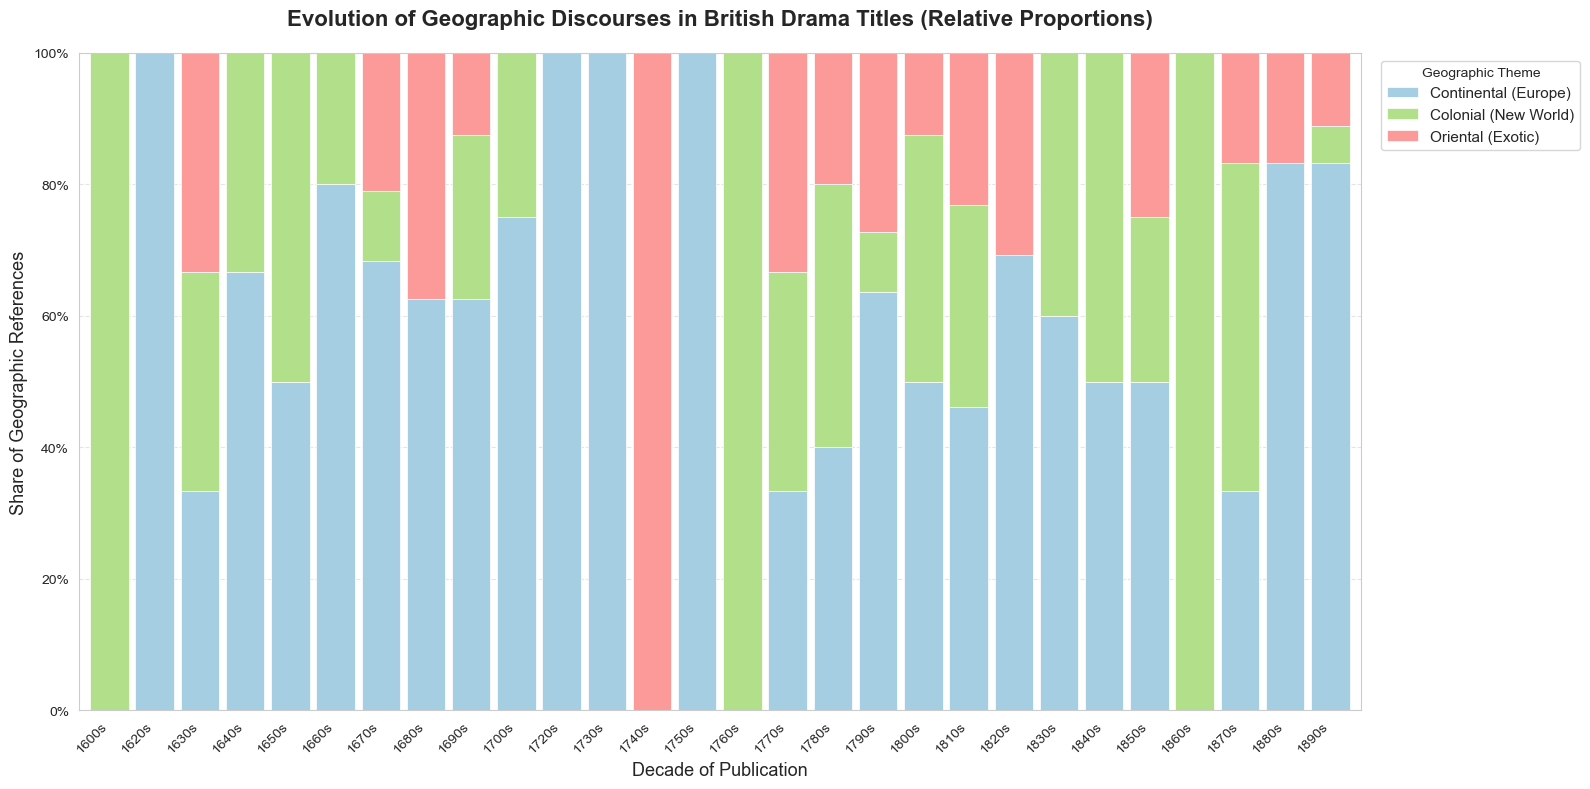

In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick 
import seaborn as sns

counts = counts.sort_values('Decade_Label')

plot_data = counts.set_index('Decade_Label')[['Pct_Continental', 'Pct_Colonial', 'Pct_Oriental']]

plot_data.columns = ['Continental (Europe)', 'Colonial (New World)', 'Oriental (Exotic)']

plot_data = plot_data.fillna(0)

sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif' 

fig, ax = plt.subplots(figsize=(16, 8))

# Generate 100% Stacked Bar Chart
plot_data.plot(kind='bar', 
               stacked=True, 
               ax=ax, 
               width=0.85, 
               color=['#a6cee3', '#b2df8a', '#fb9a99'], # Academic pastel colors
               edgecolor='white', 
               linewidth=0.5)

plt.title('Evolution of Geographic Discourses in British Drama Titles (Relative Proportions)', 
          fontsize=16, weight='bold', pad=20)
plt.xlabel('Decade of Publication', fontsize=13)
plt.ylabel('Share of Geographic References', fontsize=13)

plt.xticks(rotation=45, ha='right', fontsize=10)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.legend(title='Geographic Theme', 
           bbox_to_anchor=(1.01, 1), 
           loc='upper left', 
           frameon=True, 
           fontsize=11)

plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig('geographic_trends_plot_v2.png', dpi=300)
plt.show()


### 3.3 Privatization of Dramas: from Public History to Domestic Secrets

In [20]:
import pandas as pd
import re
from collections import Counter
import os

INPUT_FILE = 'drama_master_cleaned_final.csv'

SEED_GROUPS = {
    'Public_Discovery': {'king', 'queen', 'royal', 'state', 'war', 'empire'},
    'Private_Discovery': {'husband', 'wife', 'family', 'home', 'marriage'}
}

STOPWORDS = set([
    'the', 'a', 'an', 'of', 'and', 'in', 'to', 'for', 'with', 'by', 'on', 'at', 'etc', 'or', 'more than', 'is', 'when', 'wherein',
    'drama', 'play', 'tragedy', 'comedy', 'opera', 'farce',
    'act', 'acts', 'scene', 'prologue', 'epilogue', 
    'new', 'old', 'edition', 'printed', 'volume', 'acted', 'majesty', 
    'one', 'two', 'three', 'four', 'five', 'first', 'second', 'third', 'iii'
])

def scan_cooccurrences():
    if not os.path.exists(INPUT_FILE):
        print(f"File not found: {INPUT_FILE}")
        return

    df = pd.read_csv(INPUT_FILE)
    
    title_col = next((c for c in ['Cleaned_Title', 'title (n)', 'Title'] if c in df.columns), None)
    if not title_col:
        print("Title column not found.")
        return

    print(f"Analyzing {len(df)} titles for contextual keywords\n")

    for group_name, seeds in SEED_GROUPS.items():
        found_words = Counter()
        
        for text in df[title_col].astype(str):
            words = re.findall(r'\b[a-z]{2,}\b', text.lower())
            word_set = set(words)
            
            if word_set & seeds:
                for w in word_set:
                    if w not in seeds and w not in STOPWORDS:
                        found_words[w] += 1
        
        print(f" Top Candidates for [{group_name}] ")
        for word, count in found_words.most_common(20):
            print(f"  • {word:<12} (co-occurs {count} times)")

if __name__ == "__main__":
    scan_cooccurrences()


Analyzing 1611 titles for contextual keywords

 Top Candidates for [Public_Discovery] 
  • historical   (co-occurs 16 times)
  • elizabeth    (co-occurs 5 times)
  • mary         (co-occurs 5 times)
  • edward       (co-occurs 5 times)
  • tragi        (co-occurs 4 times)
  • england      (co-occurs 4 times)
  • james        (co-occurs 4 times)
  • his          (co-occurs 4 times)
  • scots        (co-occurs 4 times)
  • great        (co-occurs 3 times)
  • love         (co-occurs 3 times)
  • death        (co-occurs 3 times)
  • henry        (co-occurs 3 times)
  • persia       (co-occurs 3 times)
  • birth        (co-occurs 2 times)
  • mansfield    (co-occurs 2 times)
  • miller       (co-occurs 2 times)
  • tale         (co-occurs 2 times)
  • dramatic     (co-occurs 2 times)
  • scotland     (co-occurs 2 times)
 Top Candidates for [Private_Discovery] 
  • man          (co-occurs 7 times)
  • than         (co-occurs 4 times)
  • more         (co-occurs 4 times)
  • secrets      (co

 Data Loaded: 1473 titles from 1660 to 1900
 Tagging titles with updated lexicons
Chart saved as 'public_private_trend_v2_refined.png'
Tableau dataset saved as 'tableau_public_private_refined.csv'


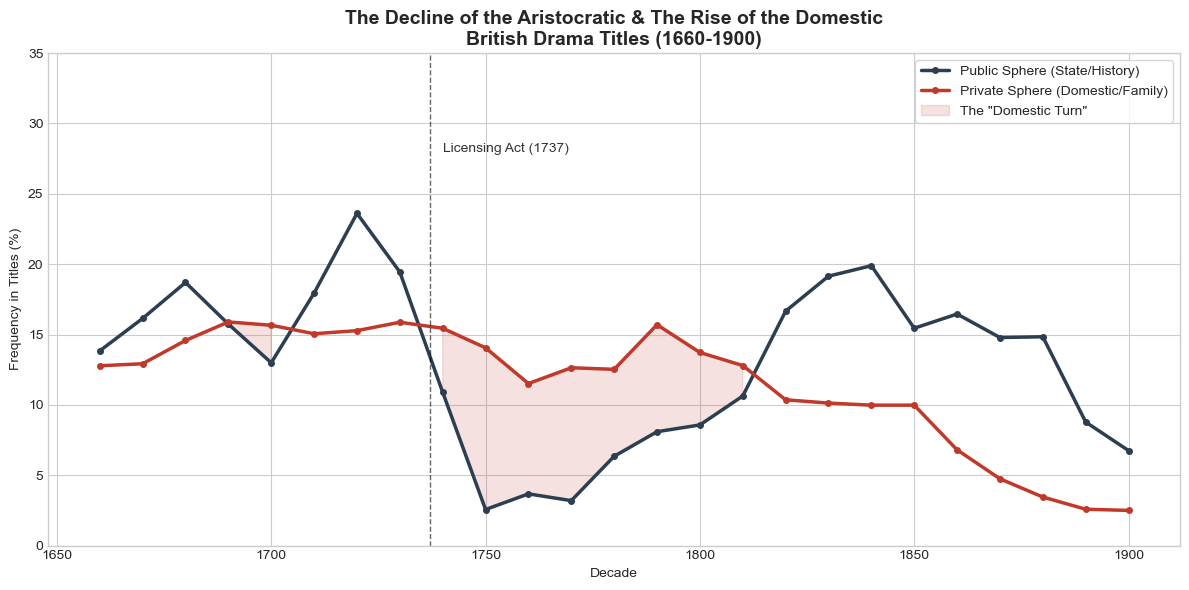

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import re

INPUT_FILE = 'drama_master_cleaned_final.csv' 
START_YEAR = 1660
END_YEAR = 1900
ROLLING_WINDOW = 3

LEXICONS = {
    'Public_Sphere': [
        'king', 'queen', 'prince', 'princess', 'royal', 'court', 'crown', 
        'throne', 'monarch', 'majesty', 'sovereign', 'empire', 'state',
        'parliament', 'senate', 'ambassador', 'governor', 'magistrate',
        'war', 'peace', 'victory', 'conquest', 'treaty',
        
        'england', 'britain', 'albion', 'rome', 'greece', 'persia', 'scots',
        
        'history', 'historical', 
        'richard', 'henry', 'charles', 'alexander', 
        'elizabeth', 'mary', 'james', 'edward', 'caesar'
    ],
    
    'Private_Sphere': [
        'husband', 'wife', 'father', 'mother', 'son', 'daughter', 
        'brother', 'sister', 'sisters', 'child', 'parent', 'widow', 'orphan', 
        'family', 'marriage', 'wedding', 'bride', 'bridegroom',
        
        'home', 'house', 'chamber', 'closet', 'garden', 'cottage', 'domestic',
        
        'jealous', 'jealousy', 'secret', 'secrets', 'fatal', 'fond',
        'reputation', 'honor', 'distress', 'divorce', 'elopement', 
        'vow', 'oath'
    ]
}

if not os.path.exists(INPUT_FILE):
    INPUT_FILE = 'dh_group7_drama_251229.csv'

try:
    df = pd.read_csv(INPUT_FILE)
    
    year_col = next((c for c in ['Publication_Year', 'p year', 'clean_year'] if c in df.columns), None)
    title_col = next((c for c in ['Cleaned_Title', 'title (n)', 'Title'] if c in df.columns), None)
    
    if not year_col or not title_col:
        raise ValueError(f"Missing columns. Found: {df.columns.tolist()}")

    df['Year_Clean'] = pd.to_numeric(df[year_col], errors='coerce')
    df = df.dropna(subset=['Year_Clean'])
    
    df = df[(df['Year_Clean'] >= START_YEAR) & (df['Year_Clean'] <= END_YEAR)]
    
    df['Decade'] = (df['Year_Clean'] // 10 * 10).astype(int)
    
    df['Title_Lower'] = df[title_col].astype(str).str.lower()
    
    print(f" Data Loaded: {len(df)} titles from {START_YEAR} to {END_YEAR}")

except Exception as e:
    print(f" Critical Error: {e}")
    exit()

print(" Tagging titles with updated lexicons")
analysis_metrics = []

for label, terms in LEXICONS.items():
    pattern = r'(?i)\b(?:' + '|'.join(terms) + r')\b'
    col_name = f'Has_{label}'
    
    df[col_name] = df['Title_Lower'].str.contains(pattern, regex=True)
    analysis_metrics.append(col_name)

all_decades = range(START_YEAR, END_YEAR + 10, 10)

df_trend = df.groupby('Decade')[analysis_metrics].mean() * 100

df_trend = df_trend.reindex(all_decades)

df_smooth = df_trend.rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 6))

colors = {'Has_Public_Sphere': '#2c3e50', 'Has_Private_Sphere': '#c0392b'}
labels = {'Has_Public_Sphere': 'Public Sphere (State/History)', 'Has_Private_Sphere': 'Private Sphere (Domestic/Family)'}

for metric in analysis_metrics:
    valid_data = df_smooth[metric].dropna()
    ax.plot(valid_data.index, valid_data, 
            label=labels[metric], 
            color=colors[metric], 
            linewidth=2.5, 
            marker='o', markersize=4)

df_interp = df_smooth.interpolate(method='linear')
ax.fill_between(df_interp.index, 
                df_interp['Has_Public_Sphere'], 
                df_interp['Has_Private_Sphere'],
                where=(df_interp['Has_Private_Sphere'] > df_interp['Has_Public_Sphere']),
                color='#c0392b', alpha=0.15, 
                label='The "Domestic Turn"')

ax.axvline(x=1737, color='black', linestyle='--', alpha=0.6, linewidth=1)
ax.text(1740, 28, 'Licensing Act (1737)', fontsize=10, rotation=0, color='#333')

# Formatting
ax.set_title(f"The Decline of the Aristocratic & The Rise of the Domestic\nBritish Drama Titles ({START_YEAR}-{END_YEAR})", fontsize=14, fontweight='bold')
ax.set_ylabel("Frequency in Titles (%)")
ax.set_xlabel("Decade")
ax.set_ylim(0, 35)
ax.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.savefig('public_private_trend_v2_refined.png', dpi=300)
print("Chart saved as 'public_private_trend_v2_refined.png'")

df_tableau = df_smooth.reset_index().rename(columns={'index': 'Decade'})
df_tableau = df_tableau.melt(id_vars=['Decade'], value_vars=analysis_metrics, 
                             var_name='Category', value_name='Percentage')

df_tableau['Category'] = df_tableau['Category'].str.replace('Has_', '', regex=False)

volume = df.groupby('Decade').size().reindex(all_decades).fillna(0).reset_index(name='Total_Titles')
df_tableau = pd.merge(df_tableau, volume, on='Decade', how='left')

df_tableau.to_csv('tableau_public_private_refined.csv', index=False)
print("Tableau dataset saved as 'tableau_public_private_refined.csv'")
